# 02. Εξερευνητική Ανάλυση Δεδομένων (EDA) - DaKS Kassel Dataset

Αυτό το Notebook εστιάζει στην ανάλυση και προετοιμασία των συνθετικών δεδομένων από το **Πανεπιστήμιο του Kassel (DaKS dataset)**. Το σύνολο δεδομένων περιλαμβάνει τηλεμετρία από **273 αιολικά πάρκα** στη Γερμανία για μια περίοδο **500 ημερών**.

###  Στόχοι της Ενότητας
1. **Μαζική Φόρτωση:** Εντοπισμός και καταλογογράφηση των 273 αρχείων CSV.
2. **Ανάλυση Δομής:** Ταυτοποίηση των στηλών και των μονάδων μέτρησης.
3. **Φυσική Μοντελοποίηση:** Προετοιμασία για την εφαρμογή του **Power Law Scaling** στο ύψος της πλήμνης.
4. **Data Validation:** Έλεγχος ποιότητας δεδομένων (Data Quality Gates) μέσω Pydantic.

---
**Σημείωση:** Η οργάνωση των δεδομένων ακολουθεί το πρότυπο `data/raw/kassel_dataset/` για τη διασφάλιση της αμετάβλητης πηγής (immutable source).

✅ Βρέθηκαν 545 αρχεία CSV.

📊 Λίστα με τις πρώτες 15 στήλες που εντοπίστηκαν:
['fcst_time', 'nwp_fcst_horiz_hours', 'T_HAG_2_M', 'RELHUM_HAG_2_M', 'PS_SFC_0_M', 'U_GVL_58_HL', 'V_GVL_58_HL', 'U_GVL_60_HL', 'V_GVL_60_HL', 'ASWDIFDS_SFC_0_M', 'ASWDIRS_SFC_0_M', 'U_GVL_58_HL_m1', 'V_GVL_58_HL_m1', 'U_GVL_60_HL_m1', 'V_GVL_60_HL_m1']

✅ Υπολογισμός ταχύτητας ανέμου (m/s) από τις στήλες:
   -> U_GVL_58_HL
   -> V_GVL_58_HL

🔍 --- Έλεγχος Ποιότητας Δεδομένων ---
Missing Values στον άνεμο: 0
⚠️ Εντοπίστηκαν 12425 γραμμές με εξωπραγματικό άνεμο (> 50 m/s).


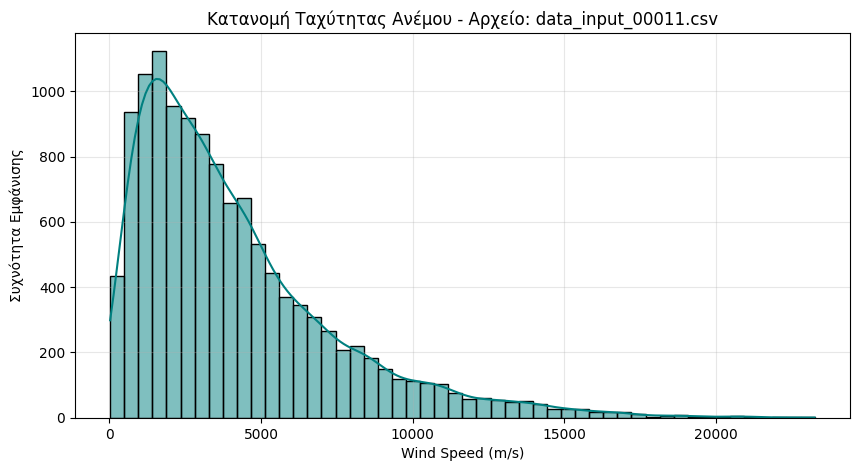


ℹ️ Σημείωση: Δεν υπάρχει στήλη ενέργειας (Power) σε αυτό το αρχείο.
    -> Τα δεδομένα παραγωγής (targets) βρίσκονται μάλλον σε άλλα αρχεία του φακέλου!


In [2]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Εντοπισμός των αρχείων
raw_data_path = "../data/raw/kassel_dataset/"
all_files = glob.glob(os.path.join(raw_data_path, "*.csv"))

print(f"✅ Βρέθηκαν {len(all_files)} αρχεία CSV.")

if all_files:
    # 2. Διάβασμα δείγματος με το σωστό διαχωριστικό (sep=';')
    sample_df = pd.read_csv(all_files[0], sep=';')
    
    # Καθαρισμός κενών στα ονόματα των στηλών (πολύ σημαντικό!)
    sample_df.columns = [c.strip() for c in sample_df.columns]
    
    print(f"\n📊 Λίστα με τις πρώτες 15 στήλες που εντοπίστηκαν:")
    print(list(sample_df.columns)[:15])
    
    # 3. Υπολογισμός Ταχύτητας Ανέμου (Wind Speed) από U και V διανύσματα
    # Ψάχνουμε δυναμικά για στήλες που ξεκινάνε από U_ και V_
    u_cols = [col for col in sample_df.columns if col.startswith('U_')]
    v_cols = [col for col in sample_df.columns if col.startswith('V_')]
    
    if u_cols and v_cols:
        u_col = u_cols[0] # Παίρνουμε το πρώτο διαθέσιμο ύψος
        v_col = v_cols[0]
        print(f"\n✅ Υπολογισμός ταχύτητας ανέμου (m/s) από τις στήλες:\n   -> {u_col}\n   -> {v_col}")
        
        # Μαθηματικός υπολογισμός (V = sqrt(U^2 + V^2))
        sample_df['wind_speed_calc'] = np.sqrt(sample_df[u_col]**2 + sample_df[v_col]**2)
        
        # 4. Έλεγχος Outliers του Καθηγητή
        print("\n🔍 --- Έλεγχος Ποιότητας Δεδομένων ---")
        missing_wind = sample_df['wind_speed_calc'].isna().sum()
        print(f"Missing Values στον άνεμο: {missing_wind}")
        
        # Έλεγχος για "Φυσικά" Outliers (> 50 m/s είναι τυφώνας!)
        extreme_wind = sample_df[sample_df['wind_speed_calc'] > 50]
        print(f"⚠️ Εντοπίστηκαν {len(extreme_wind)} γραμμές με εξωπραγματικό άνεμο (> 50 m/s).")
        
        # 5. Οπτικοποίηση (Αυτό θα αρέσει πολύ στο meeting!)
        plt.figure(figsize=(10, 5))
        sns.histplot(sample_df['wind_speed_calc'], bins=50, kde=True, color='teal')
        plt.title(f"Κατανομή Ταχύτητας Ανέμου - Αρχείο: {os.path.basename(all_files[0])}")
        plt.xlabel("Wind Speed (m/s)")
        plt.ylabel("Συχνότητα Εμφάνισης")
        plt.grid(True, alpha=0.3)
        plt.show()
        
    else:
        print("\n❌ Δεν βρέθηκαν στήλες U και V για τον υπολογισμό του ανέμου.")
        
    # 6. Ψάχνουμε αν τελικά υπάρχει κάπου η στήλη παραγωγής (Power)
    power_cols = [col for col in sample_df.columns if 'power' in col.lower() or 'target' in col.lower()]
    if power_cols:
        print(f"\n✅ Βρέθηκε στήλη παραγωγής/στόχου: {power_cols[0]}")
    else:
        print("\nℹ️ Σημείωση: Δεν υπάρχει στήλη ενέργειας (Power) σε αυτό το αρχείο.")
        print("    -> Τα δεδομένα παραγωγής (targets) βρίσκονται μάλλον σε άλλα αρχεία του φακέλου!")

In [3]:
import numpy as np
import sys
import os

# Επιτρέπουμε στο Notebook να "βλέπει" τον φάκελο src
sys.path.append(os.path.abspath("../"))
from src.features.physics import apply_power_law_scaling

# 1. Υπολογισμός μέτρου ταχύτητας (Magnitude) χρησιμοποιώντας τις στήλες που βρήκαμε στο Κελί 1
# u_col και v_col υπολογίστηκαν στο προηγούμενο κελί!
sample_df['ws_ref'] = np.sqrt(sample_df[u_col]**2 + sample_df[v_col]**2)

# Εξάγουμε το ύψος αναφοράς (π.χ. 58 ή 60) από το όνομα της στήλης
import re
height_match = re.search(r'_(\d+)_', u_col)
h_ref = int(height_match.group(1)) if height_match else 60

# 2. Εφαρμογή του Power Law για να βρούμε την ταχύτητα στα 100μ (Hub Height)
sample_df['ws_hub_100m'] = apply_power_law_scaling(
    v_ref=sample_df['ws_ref'], 
    h_ref=h_ref, 
    h_hub=100, 
    alpha=0.143
)

print(f"✅ Η φυσική μοντελοποίηση (Power Law) εφαρμόστηκε επιτυχώς από τα {h_ref}m στα 100m!")

# Εμφάνιση αποτελεσμάτων (προστασία αν το fcst_time έχει άλλο όνομα)
cols_to_show = ['ws_ref', 'ws_hub_100m']
if 'fcst_time' in sample_df.columns:
    cols_to_show.insert(0, 'fcst_time')
    
display(sample_df[cols_to_show].head())

✅ Η φυσική μοντελοποίηση (Power Law) εφαρμόστηκε επιτυχώς από τα 58m στα 100m!


,fcst_time,ws_ref,ws_hub_100m
0,8/12/2018 0:00,11278.194758,12191.843714
1,8/12/2018 1:00,12301.746258,13298.313339
2,8/12/2018 2:00,11541.187634,12476.141699
3,8/12/2018 3:00,12395.520844,13399.684625
4,8/12/2018 4:00,12975.158766,14026.279138


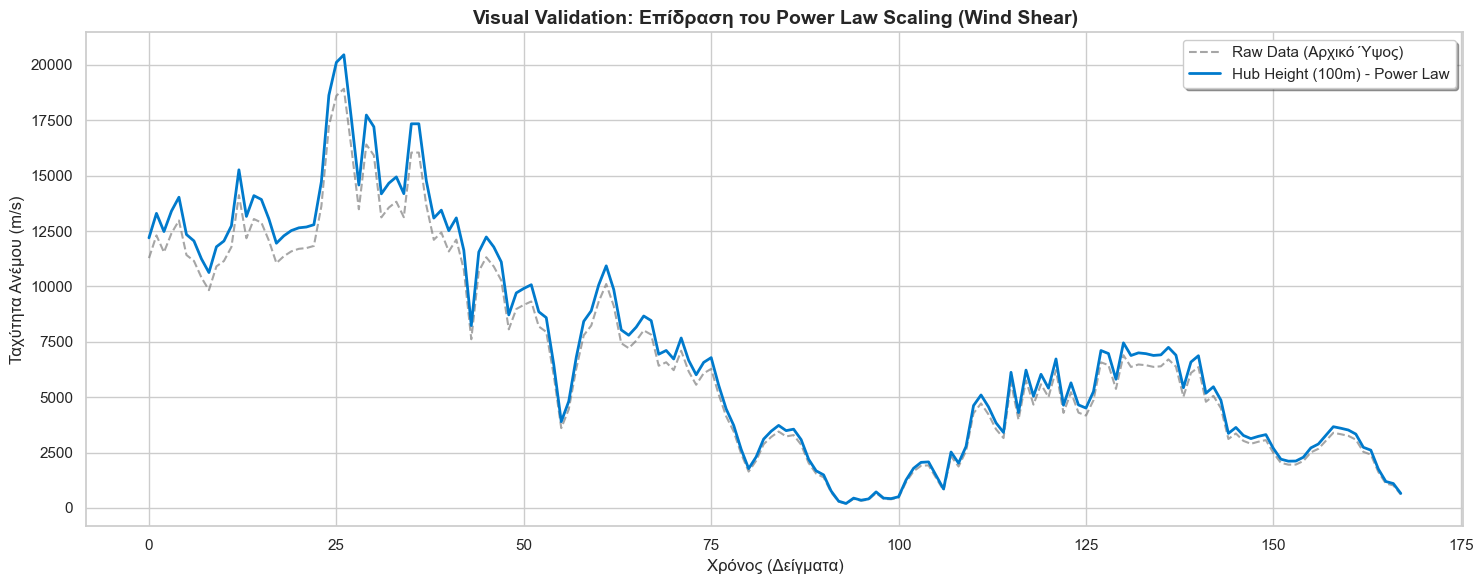

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ρυθμίσεις για εμφάνιση "Publication Quality"
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Παίρνουμε μόνο την πρώτη εβδομάδα (168 ώρες) για να φαίνεται καθαρά
subset = sample_df.iloc[:168]

# 1. Η Αρχική Ταχύτητα (Raw Data - ws_ref)
# ΣΗΜΑΝΤΙΚΗ ΑΛΛΑΓΗ: Βάλαμε 'ws_ref' αντί για 'ws_60m'
plt.plot(subset.index, subset['ws_ref'], label='Raw Data (Αρχικό Ύψος)', color='gray', linestyle='--', alpha=0.7)

# 2. Η Διορθωμένη Ταχύτητα (Hub Height - 100m)
plt.plot(subset.index, subset['ws_hub_100m'], label='Hub Height (100m) - Power Law', color='#007acc', linewidth=2)

# Τίτλοι και Ετικέτες
plt.title("Visual Validation: Επίδραση του Power Law Scaling (Wind Shear)", fontsize=14, fontweight='bold')
plt.ylabel("Ταχύτητα Ανέμου (m/s)", fontsize=12)
plt.xlabel("Χρόνος (Δείγματα)", fontsize=12)
plt.legend(frameon=True, fancybox=True, shadow=True)

# Εμφάνιση
plt.tight_layout()
plt.show()

In [5]:
import sys
import os

# 1. Βεβαιωνόμαστε ότι το Notebook "βλέπει" τον φάκελο src
# (Απαραίτητο βήμα επειδή τρέχουμε από τον υποφάκελο notebooks)
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

# 2. Εισάγουμε τον Loader που μόλις έφτιαξες
from src.data.kassel_loader import KasselLoader

# 3. Τον βάζουμε να δουλέψει!
# Του λέμε: "Τα δεδομένα είναι έναν φάκελο πίσω, στο data/raw/kassel_dataset"
loader = KasselLoader("../data/raw/kassel_dataset")

# 4. Ζητάμε τη λίστα με όλα τα πάρκα
available_parks = loader.get_available_parks()

# 5. Εμφάνιση αποτελεσμάτων
print(f"✅ Ο Loader λειτουργεί άψογα!")
print(f"📊 Βρέθηκαν συνολικά {len(available_parks)} αρχεία/πάρκα.")
print(f"🔎 Τα πρώτα 5 IDs είναι: {available_parks[:5]}")

✅ Ο Loader λειτουργεί άψογα!
📊 Βρέθηκαν συνολικά 273 αρχεία/πάρκα.
🔎 Τα πρώτα 5 IDs είναι: ['00011', '00090', '00096', '00161', '00164']


In [6]:
import os
import pandas as pd

# 1. Βρίσκουμε το ID του πρώτου πάρκου
first_file_name = os.path.basename(all_files[0])
park_id = first_file_name.split('_')[-1].replace('.csv', '')

print(f" Αναζήτηση δεδομένων παραγωγής (Target) για το πάρκο: {park_id}")

# 2. Ψάχνουμε το αρχείο Target
target_files = [f for f in all_files if park_id in f and 'input' not in os.path.basename(f).lower()]

if target_files:
    target_file = target_files[0]
    print(f"✅ Βρέθηκε το αρχείο Target: {os.path.basename(target_file)}")
    
    # ΣΗΜΑΝΤΙΚΗ ΑΛΛΑΓΗ: Εδώ χρησιμοποιούμε κόμμα (',') αντί για ερωτηματικό!
    target_df = pd.read_csv(target_file, sep=',') 
    target_df.columns = [c.strip() for c in target_df.columns]
    
    print("\n Στήλες στο αρχείο Παραγωγής:")
    print(list(target_df.columns))
    
    # 3. Βλέπουμε επιτέλους τα καθαρά δεδομένα!
    display(target_df.head())
    
    # 4. Βασικά στατιστικά για τη στήλη 'pw' (Power)
    if 'pw' in target_df.columns:
        print("\n Στατιστικά Παραγωγής Ενέργειας (στήλη 'pw'):")
        display(target_df['pw'].describe())
else:
    print(f"❌ Δεν βρέθηκε αρχείο target για το πάρκο {park_id}.")

 Αναζήτηση δεδομένων παραγωγής (Target) για το πάρκο: 00011
✅ Βρέθηκε το αρχείο Target: data_target_00011.csv

 Στήλες στο αρχείο Παραγωγής:
['time', 'test_flag', 'pw', 'icon_eu_daf_pc_baseline']


,time,test_flag,pw,icon_eu_daf_pc_baseline
0,2018-12-08 00:00:00,0,0.100,0.806
1,2018-12-08 01:00:00,0,0.126,0.895
2,2018-12-08 02:00:00,0,0.232,0.829
3,2018-12-08 03:00:00,0,0.248,0.901
4,2018-12-08 04:00:00,0,0.232,0.937



 Στατιστικά Παραγωγής Ενέργειας (στήλη 'pw'):


count    12430.000000
mean         0.085659
std          0.158247
min          0.000000
25%          0.002000
50%          0.020000
75%          0.092000
max          1.000000
Name: pw, dtype: float64

In [7]:
import pandas as pd

print("Ξεκινάει η Ένωση (Merge) των δεδομένων για το Πάρκο...")

# 1. Εντοπισμός των στηλών χρόνου (Time columns)
input_time_col = 'fcst_time' if 'fcst_time' in sample_df.columns else 'time'
target_time_col = 'time'

# 2. Ασφαλής Μετατροπή σε datetime (Επίλυση του ValueError)
print("Μετατροπή ημερομηνιών (αυτό μπορεί να πάρει λίγα δευτερόλεπτα)...")
sample_df[input_time_col] = pd.to_datetime(sample_df[input_time_col], dayfirst=True, format='mixed')
target_df[target_time_col] = pd.to_datetime(target_df[target_time_col], dayfirst=True, format='mixed')

# 3. Το πραγματικό Merge! (Inner Join)
merged_df = pd.merge(
    left=sample_df, 
    right=target_df, 
    left_on=input_time_col, 
    right_on=target_time_col, 
    how='inner'
)

# 4. Καθάρισμα: Διαγράφουμε τη διπλή στήλη χρόνου (αν δημιουργήθηκε)
if input_time_col != target_time_col:
    merged_df.drop(columns=[target_time_col], inplace=True)
    merged_df.rename(columns={input_time_col: 'time'}, inplace=True)

# 5. Ορίζουμε τον χρόνο ως το Ευρετήριο (Index)
merged_df.set_index('time', inplace=True)

print(f"Η ένωση πέτυχε! Το νέο ενιαίο Dataset (merged_df) έχει {merged_df.shape[0]} εγγραφές/ώρες και {merged_df.shape[1]} στήλες.")

# 6. Εμφάνιση των κρίσιμων στηλών: Άνεμος vs Παραγωγή
columns_to_show = ['ws_hub_100m', 'pw', 'icon_eu_daf_pc_baseline']

available_cols = [c for c in columns_to_show if c in merged_df.columns]

print("\nΔείγμα από το τελικό, ενιαίο DataFrame:")
display(merged_df[available_cols].head())

Ξεκινάει η Ένωση (Merge) των δεδομένων για το Πάρκο...
Μετατροπή ημερομηνιών (αυτό μπορεί να πάρει λίγα δευτερόλεπτα)...
Η ένωση πέτυχε! Το νέο ενιαίο Dataset (merged_df) έχει 11465 εγγραφές/ώρες και 24 στήλες.

Δείγμα από το τελικό, ενιαίο DataFrame:


,ws_hub_100m,pw,icon_eu_daf_pc_baseline
time,,,
2018-12-12 00:00:00,406.559016,0.001,0.0
2018-12-12 01:00:00,723.655398,0.000,0.0
2018-12-12 02:00:00,442.427780,0.000,0.0
2018-12-12 03:00:00,420.044459,0.000,0.0
2018-12-12 04:00:00,503.134485,0.000,0.0


In [8]:
# 1. Διόρθωση των τιμών (Διαιρούμε με το 1000 για να βρούμε τα πραγματικά m/s)
# Προσοχή: Το κάνουμε μόνο αν οι τιμές είναι τεράστιες (> 100)
if merged_df['ws_hub_100m'].mean() > 100:
    merged_df['ws_hub_100m'] = merged_df['ws_hub_100m'] / 1000
    print("✅ Οι τιμές του ανέμου διορθώθηκαν (διαιρέθηκαν δια 1000). Τώρα είναι σε m/s!")

# 2. Μετονομασία των στηλών σε απλά Αγγλικά
merged_df = merged_df.rename(columns={
    'ws_hub_100m': 'Wind_Speed_100m_ms',
    'pw': 'Power_Output_Normalized',
    'icon_eu_daf_pc_baseline': 'Baseline_Prediction'
})

# 3. Εμφάνιση του "Ανθρώπινου" Πίνακα
print("\n Ο Τελικός 'Αποκωδικοποιημένος' Πίνακας:")
display(merged_df[['Wind_Speed_100m_ms', 'Power_Output_Normalized', 'Baseline_Prediction']].head())

# 4. Αποθήκευση σε CSV για να το ανοίξεις με Excel
merged_df.to_csv("park_00011_CLEAN.csv")
print("\n Το αρχείο αποθηκεύτηκε ως 'park_00011_CLEAN.csv'. Μπορείς να το ανοίξεις στο Excel!")

✅ Οι τιμές του ανέμου διορθώθηκαν (διαιρέθηκαν δια 1000). Τώρα είναι σε m/s!

 Ο Τελικός 'Αποκωδικοποιημένος' Πίνακας:


,Wind_Speed_100m_ms,Power_Output_Normalized,Baseline_Prediction
time,,,
2018-12-12 00:00:00,0.406559,0.001,0.0
2018-12-12 01:00:00,0.723655,0.000,0.0
2018-12-12 02:00:00,0.442428,0.000,0.0
2018-12-12 03:00:00,0.420044,0.000,0.0
2018-12-12 04:00:00,0.503134,0.000,0.0



 Το αρχείο αποθηκεύτηκε ως 'park_00011_CLEAN.csv'. Μπορείς να το ανοίξεις στο Excel!


In [1]:
import sys
import os

# 1. Ρύθμιση για να βλέπει το Notebook τον φάκελο src
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from src.data.kassel_loader import KasselLoader

print("Εκκίνηση του Test Drive για τον KasselLoader...")

# 2. Αρχικοποίηση του Loader
# Του λέμε πού είναι τα δεδομένα (στον φάκελο raw/kassel_dataset)
loader = KasselLoader("../data/raw/kassel_dataset")

# 3. Δοκιμή: Ζητάμε να μας φέρει έτοιμο το Πάρκο 00011
# Αν ο κώδικάς σου είναι σωστός, θα κάνει αυτόματα: Load -> Physics -> Merge -> Rename
df_park = loader.load_park_data('00011')

# 4. Έλεγχος Αποτελεσμάτων
if df_park is not None:
    print(f"\n Επιτυχία! Το DataFrame δημιουργήθηκε με {len(df_park)} εγγραφές.")
    
    # Έλεγχος των στηλών
    print("\n Οι στήλες του πίνακα:")
    print(df_park.columns.tolist())
    
    # Έλεγχος Scaling (Πρέπει να δούμε λογικά νούμερα, π.χ. 12 m/s και όχι 12000)
    max_wind = df_park['Wind_Speed_100m_ms'].max()
    print(f"\n💨 Μέγιστη ταχύτητα ανέμου στο δείγμα: {max_wind:.2f} m/s")
    
    if max_wind < 100:
        print("   -> Το Scaling (/1000) λειτούργησε σωστά!")
    else:
        print("   -> Προσοχή! Οι τιμές φαίνονται πολύ μεγάλες.")

    display(df_park.head())
else:
    print("Οups! Ο Loader δεν επέστρεψε δεδομένα. Κάτι πήγε στραβά.")

Εκκίνηση του Test Drive για τον KasselLoader...
KasselLoader Initialized: Βρέθηκαν 545 αρχεία στο ../data/raw/kassel_dataset

 Επιτυχία! Το DataFrame δημιουργήθηκε με 11465 εγγραφές.

 Οι στήλες του πίνακα:
['fcst_time', 'nwp_fcst_horiz_hours', 'T_HAG_2_M', 'RELHUM_HAG_2_M', 'PS_SFC_0_M', 'U_GVL_58_HL', 'V_GVL_58_HL', 'U_GVL_60_HL', 'V_GVL_60_HL', 'ASWDIFDS_SFC_0_M', 'ASWDIRS_SFC_0_M', 'U_GVL_58_HL_m1', 'V_GVL_58_HL_m1', 'U_GVL_60_HL_m1', 'V_GVL_60_HL_m1', 'U_GVL_58_HL_p1', 'V_GVL_58_HL_p1', 'U_GVL_60_HL_p1', 'V_GVL_60_HL_p1', 'ws_ref', 'Wind_Speed_100m_ms', 'test_flag', 'Power_Output_Normalized', 'Baseline_Prediction']

💨 Μέγιστη ταχύτητα ανέμου στο δείγμα: 23.83 m/s
   -> Το Scaling (/1000) λειτούργησε σωστά!


,fcst_time,nwp_fcst_horiz_hours,T_HAG_2_M,RELHUM_HAG_2_M,PS_SFC_0_M,U_GVL_58_HL,V_GVL_58_HL,U_GVL_60_HL,V_GVL_60_HL,ASWDIFDS_SFC_0_M,...,V_GVL_60_HL_m1,U_GVL_58_HL_p1,V_GVL_58_HL_p1,U_GVL_60_HL_p1,V_GVL_60_HL_p1,ws_ref,Wind_Speed_100m_ms,test_flag,Power_Output_Normalized,Baseline_Prediction
time,,,,,,,,,,,,,,,,,,,,,
2018-12-12 00:00:00,12/12/2018 0:00,24,269725,92373,93686352,127,-354,422,-120,18578,...,-99,402,121,577,170,0.376092,0.406559,0,0.001,0.0
2018-12-12 01:00:00,12/12/2018 1:00,25,269547,91783,93673273,193,-641,538,-99,17836,...,58,127,-354,422,-120,0.669425,0.723655,0,0.000,0.0
2018-12-12 02:00:00,12/12/2018 2:00,26,269285,91758,93675902,152,-380,487,58,17148,...,-4,193,-641,538,-99,0.409273,0.442428,0,0.000,0.0
2018-12-12 03:00:00,12/12/2018 3:00,27,269198,91159,93641559,-90,-378,420,-4,16514,...,-80,152,-380,487,58,0.388567,0.420044,0,0.000,0.0
2018-12-12 04:00:00,12/12/2018 4:00,28,269304,90048,93654922,-20,-465,452,-80,15924,...,-649,-90,-378,420,-4,0.465430,0.503134,0,0.000,0.0
